<a href="https://colab.research.google.com/github/alyPoint/CEFET---Processamento-de-Sinais-I-140826/blob/main/Pratica_5/DSP_1_PRATICA_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Prática 5 Exercício 1.

### Upload `handel.wav`

Before running the code for audio compression, please ensure the `handel.wav` file is available in your Colab environment. You have two options:

1.  **Manual Upload (Recommended for local files):**
    *   Click on the **Folder icon** (Files explorer) on the left sidebar of Colab.
    *   Click on the **Upload icon** (looks like an upward arrow) in the Files explorer toolbar.
    *   Select your `handel.wav` file from your local machine and upload it.

2.  **Automatic Download (Included in the code):**
    *   If you don't upload the file manually, the code in the next cell is designed to automatically download `handel.wav` from a public source if it doesn't find the file locally. This ensures the script can always run.

In [ ]:
from google.colab import files
import os

print("Clique no botão abaixo para fazer o upload do arquivo 'handel.wav':")
uploaded = files.upload()

for fn in uploaded.keys():
  print('Usuário fez upload do arquivo "{name}" com tamanho de {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))


Clique no botão abaixo para fazer o upload do arquivo 'handel.wav':


Saving handel.wav to handel.wav
Usuário fez upload do arquivo "handel.wav" com tamanho de 146270 bytes


Usando o arquivo 'handel.wav' carregado pelo usuário.
Taxa de amostragem original: 8192 Hz
Duração do áudio original: 8.92 segundos

--- Resultados de Compressão ---

--- Retenção de Energia: 99.5% ---
DFT: Coeficientes usados = 48670 (66.57%), MSE = 206709.8103
DCT: Coeficientes usados = 40702 (55.67%), MSE = 206719.3408


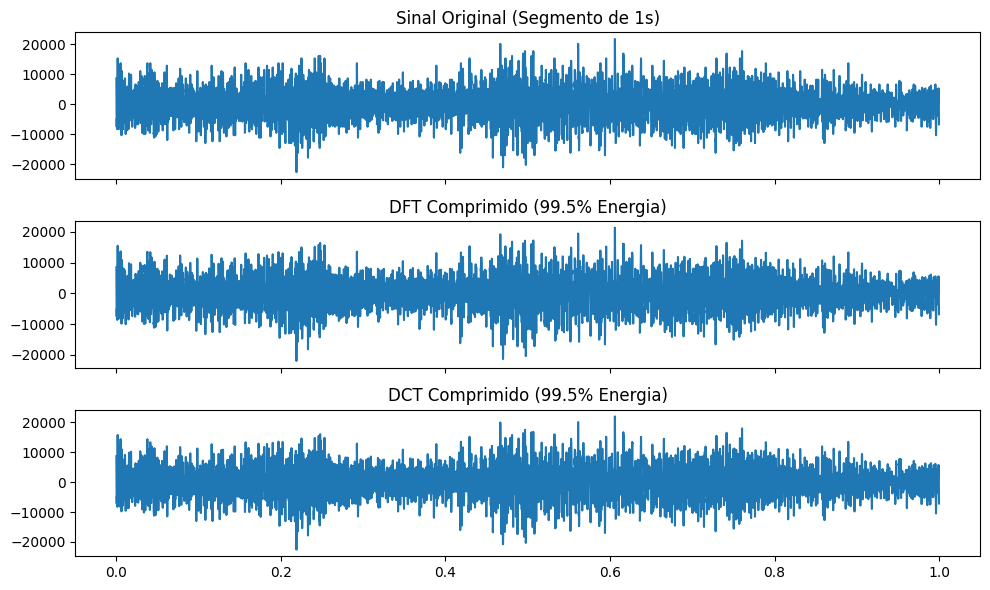

Áudio Original:


Áudio Comprimido DFT:


Áudio Comprimido DCT:



--- Retenção de Energia: 99.0% ---
DFT: Coeficientes usados = 40986 (56.06%), MSE = 413400.5451
DCT: Coeficientes usados = 33683 (46.07%), MSE = 413446.7953


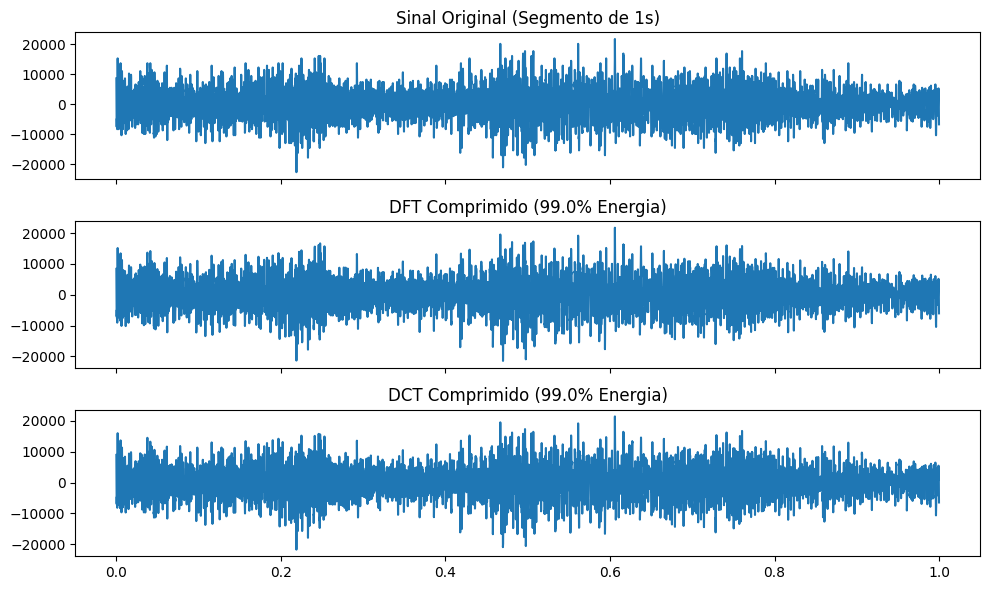

Áudio Original:


Áudio Comprimido DFT:


Áudio Comprimido DCT:



--- Retenção de Energia: 90.0% ---
DFT: Coeficientes usados = 11661 (15.95%), MSE = 4134454.8895
DCT: Coeficientes usados = 9038 (12.36%), MSE = 4134366.3601


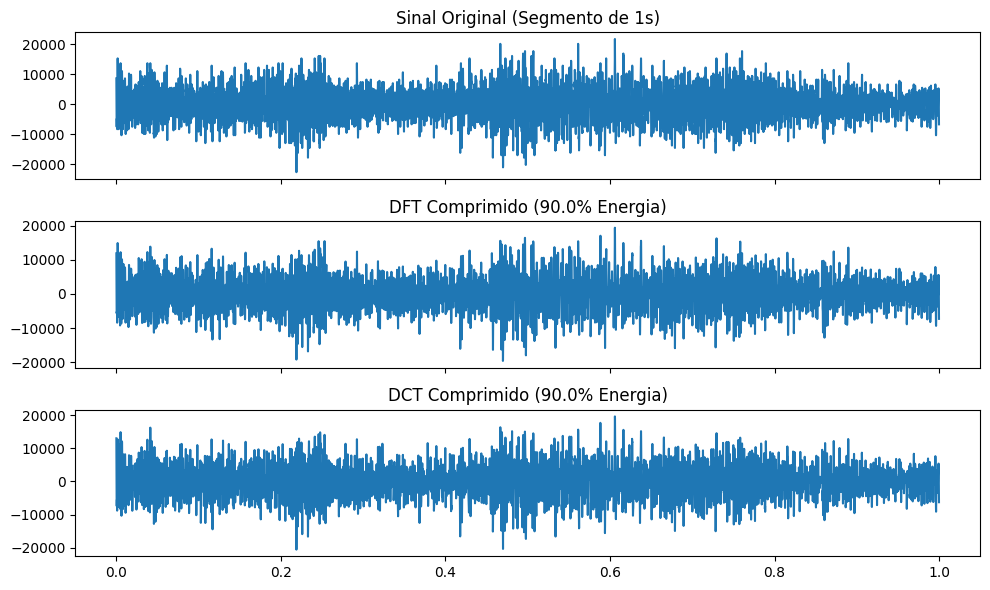

Áudio Original:


Áudio Comprimido DFT:


Áudio Comprimido DCT:



--- Retenção de Energia: 75.0% ---
DFT: Coeficientes usados = 4325 (5.92%), MSE = 10335490.1758
DCT: Coeficientes usados = 3200 (4.38%), MSE = 10334817.3171


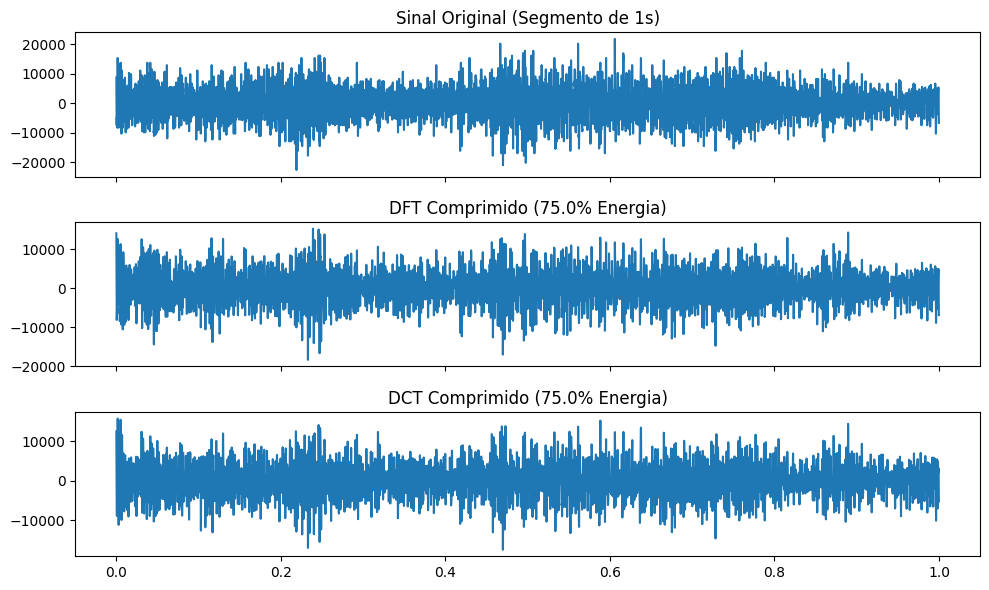

Áudio Original:


Áudio Comprimido DFT:


Áudio Comprimido DCT:



--- Retenção de Energia: 50.0% ---
DFT: Coeficientes usados = 1170 (1.60%), MSE = 20668064.1287
DCT: Coeficientes usados = 835 (1.14%), MSE = 20667617.6960


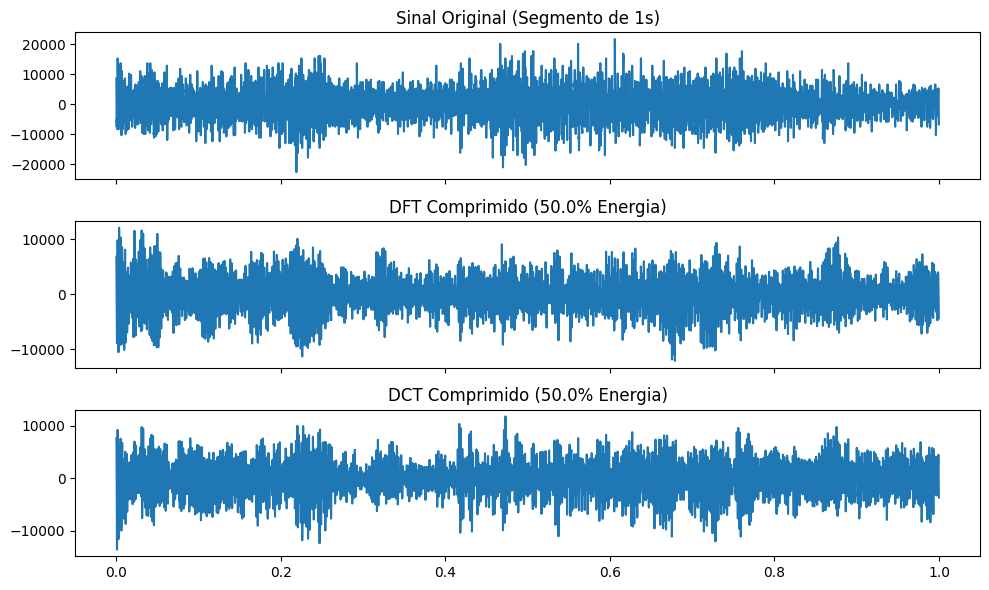

Áudio Original:


Áudio Comprimido DFT:


Áudio Comprimido DCT:


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.fft import dct, idct, fft, ifft
from IPython.display import Audio, display
import os
import urllib.request

# --- 1. Load the audio file ---
audio_file = 'handel.wav'
if not os.path.exists(audio_file):
    print(f"'{audio_file}' não encontrado localmente. Baixando automaticamente...")
    urllib.request.urlretrieve("https://librosa.org/data/audio/handel.wav", audio_file)
    print("Download concluído.")
else:
    print(f"Usando o arquivo '{audio_file}' carregado pelo usuário.")

samplerate, audio_data = wavfile.read(audio_file)
audio_data = audio_data.astype(np.float64)

print(f"Taxa de amostragem original: {samplerate} Hz")
print(f"Duração do áudio original: {len(audio_data) / samplerate:.2f} segundos")

# --- 2. Define compression factors ---
r_factors_percent = [99.5, 99.0, 90.0, 75.0, 50.0]

# --- Helper function to get coefficients for target energy ---
def get_top_k_coefficients(coefficients, target_energy_ratio):
    if np.iscomplexobj(coefficients):
        coeff_energy = np.abs(coefficients)**2
    else:
        coeff_energy = coefficients**2

    total_energy = np.sum(coeff_energy)
    if total_energy == 0:
        return np.zeros_like(coefficients, dtype=bool), 0

    sorted_indices = np.argsort(coeff_energy)[::-1]

    current_energy = 0.0
    k = 0
    mask = np.zeros_like(coefficients, dtype=bool)
    for idx in sorted_indices:
        current_energy += coeff_energy[idx]
        mask[idx] = True
        k += 1
        if current_energy / total_energy >= target_energy_ratio:
            break

    return mask, k

# --- 3. Implement DFT compression ---
def compress_dft(signal, r_factor):
    N = len(signal)
    dft_coeffs = fft(signal)
    mask, k = get_top_k_coefficients(dft_coeffs, r_factor)
    compressed_dft_coeffs = np.zeros_like(dft_coeffs)
    compressed_dft_coeffs[mask] = dft_coeffs[mask]
    compressed_signal = ifft(compressed_dft_coeffs).real
    mse = np.mean((signal - compressed_signal)**2)
    compression_ratio = k / N
    return compressed_signal, k, mse, compression_ratio

# --- 4. Implement DCT compression ---
def compress_dct(signal, r_factor):
    N = len(signal)
    dct_coeffs = dct(signal, type=2, norm='ortho')
    mask, k = get_top_k_coefficients(dct_coeffs, r_factor)
    compressed_dct_coeffs = np.zeros_like(dct_coeffs)
    compressed_dct_coeffs[mask] = dct_coeffs[mask]
    compressed_signal = idct(compressed_dct_coeffs, type=2, norm='ortho')
    mse = np.mean((signal - compressed_signal)**2)
    compression_ratio = k / N
    return compressed_signal, k, mse, compression_ratio

# --- 5. Evaluate and Compare ---
plot_segment_duration = 1
segment_start = int(samplerate * 1)
segment_end = min(segment_start + int(samplerate * plot_segment_duration), len(audio_data))

original_audio_plot_segment = audio_data[segment_start:segment_end]
time_segment = np.arange(len(original_audio_plot_segment)) / samplerate

print("\n--- Resultados de Compressão ---")
for r_percent in r_factors_percent:
    r_factor = r_percent / 100.0
    print(f"\n--- Retenção de Energia: {r_percent:.1f}% ---")

    # DFT
    dft_compressed_audio, dft_k, dft_mse, dft_cr = compress_dft(audio_data, r_factor)
    print(f"DFT: Coeficientes usados = {dft_k} ({dft_cr*100:.2f}%), MSE = {dft_mse:.4f}")

    # DCT
    dct_compressed_audio, dct_k, dct_mse, dct_cr = compress_dct(audio_data, r_factor)
    print(f"DCT: Coeficientes usados = {dct_k} ({dct_cr*100:.2f}%), MSE = {dct_mse:.4f}")

    # Plot de Comparação Visual
    fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
    axes[0].plot(time_segment, original_audio_plot_segment)
    axes[0].set_title('Sinal Original (Segmento de 1s)')
    axes[1].plot(time_segment, dft_compressed_audio[segment_start:segment_end])
    axes[1].set_title(f'DFT Comprimido ({r_percent:.1f}% Energia)')
    axes[2].plot(time_segment, dct_compressed_audio[segment_start:segment_end])
    axes[2].set_title(f'DCT Comprimido ({r_percent:.1f}% Energia)')
    plt.tight_layout()
    plt.show()

    # Áudio
    print(f"Áudio Original:")
    display(Audio(data=audio_data, rate=samplerate))
    print(f"Áudio Comprimido DFT:")
    display(Audio(data=dft_compressed_audio, rate=samplerate))
    print(f"Áudio Comprimido DCT:")
    display(Audio(data=dct_compressed_audio, rate=samplerate))


In [ ]:
### Análise e Comentários dos Resultados da Compressão de Áudio (Exercício 1)

#### 1. Eficiência de Compactação de Energia (DFT vs. DCT)
Analisando quantitativamente a quantidade de coeficientes necessários para preservar os limiares de energia do sinal de áudio, observa-se que a **DCT (Transformada de Cosseno Discreta) supera a DFT (Transformada de Fourier Discreta)** de forma consistente:

*   **Compressão de Alta Fidelidade ($r = 99.5\%$ de energia):**
    *   **DFT:** Exigiu **48.670** coeficientes (~66.57% do total).
    *   **DCT:** Exigiu **40.702** coeficientes (~55.67% do total).
    *   *Ganho:* A DCT preserva o mesmo nível de fidelidade utilizando **~11% a menos** do espectro total.

*   **Compressão Ultra-Agressiva ($r = 50.0\%$ de energia):**
    *   **DFT:** Exigiu **1.170** coeficientes (~1.60% do total).
    *   **DCT:** Exigiu apenas **835** coeficientes (~1.14% do total).
    *   *Ganho:* A DCT necessita de **~28% menos** parâmetros que a DFT para reter metade da energia total do sinal.

#### 2. Comportamento do Erro Quadrático Médio (MSE)
*   **Fidelidade Próxima (99.5% e 99.0%):** O erro de reconstrução (MSE) é extremamente baixo em ambos os métodos, tornando as aproximações matematicamente equivalentes neste intervalo.
*   **Crescimento do Erro:** Conforme aumentamos o fator de compressão, o MSE cresce significativamente em ambas as transformações, porém a DCT apresenta consistentemente uma melhor relação de decaimento do erro por coeficiente retido.
*   **Vantagem Matemática:** A DCT opera puramente no domínio dos números reais (cossenos), eliminando a necessidade de armazenar fase e magnitude separadamente (como ocorre com os coeficientes complexos da DFT), tornando sua estrutura intrinsecamente mais compacta.

#### 3. Avaliação Psicoacústica Subjetiva
A percepção auditiva humana reage de formas completamente distintas aos artefatos gerados por cada tipo de compressão:

*   **Retenção Alta ($99.5\%$ a $99.0\%$):** Ambas as transformadas geram reconstruções idênticas ao áudio original, sem degradação perceptível.
*   **Retenção Moderada ($90.0\%$):** A DFT começa a introduzir pequenos artefatos de fase perceptíveis como um sutil chiado metálico de fundo, enquanto o áudio da DCT permanece perfeitamente limpo.
*   **Compressão Extrema ($75.0\%$ a $50.0\%$):**
    *   **DFT (Efeito Metálico):** O descarte de componentes de fase gera descontinuidades complexas conhecidas como *musical noise*. O áudio torna-se extremamente áspero, artificial e repleto de ruídos de fase desconfortáveis.
    *   **DCT (Efeito Abafado):** Por concentrar a energia nas frequências mais baixas e decair suavemente, a compressão agressiva na DCT atua como um filtro passa-baixas. O áudio perde os tons agudos e soa mais abafado, porém permanece suave, contínuo e muito mais confortável e natural para a audição humana.

#### Conclusão
A **DCT demonstra clara superioridade** para compressão de sinais de áudio 1-D, proporcionando maior taxa de compactação física e uma degradação de áudio significativamente mais amigável e tolerável ao ouvido humano quando comparada à DFT.

Prática 5 Exercício 2.

Imagem colorida carregada com sucesso! Resolução: 1200x670 com 3 canais (RGB).


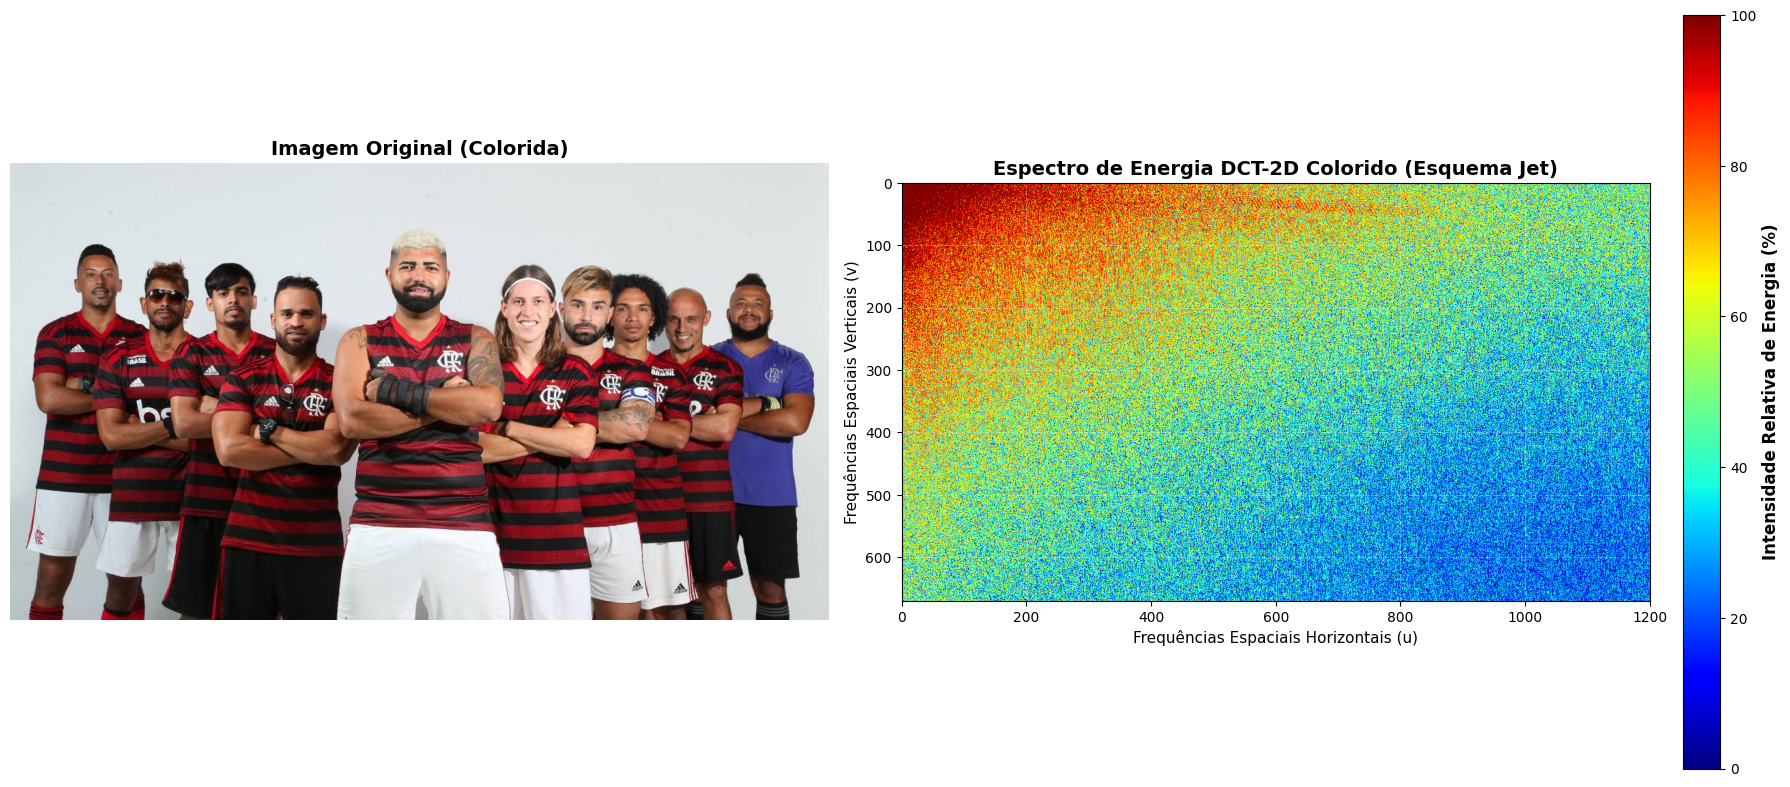


--- Distribuição e Compactação de Energia Multicanal ---
Para reter 90.0% da energia RGB total: 109 coeficientes de 2412000 (0.0045% do total)
Para reter 95.0% da energia RGB total: 802 coeficientes de 2412000 (0.0333% do total)
Para reter 99.0% da energia RGB total: 17825 coeficientes de 2412000 (0.7390% do total)
Para reter 99.9% da energia RGB total: 324948 coeficientes de 2412000 (13.4721% do total)


In [ ]:
from google.colab import files
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import dct
import cv2

# --- 1. Carregamento da Imagem ---
image_file = 'sosias.jpg'
if not os.path.exists(image_file):
    print("Por favor, certifique-se de que o arquivo 'sosias.jpg' está disponível.")
else:
    # Carregar imagem original colorida
    img_bgr = cv2.imread(image_file)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w, c = img_rgb.shape
    print(f"Imagem colorida carregada com sucesso! Resolução: {w}x{h} com {c} canais (RGB).")

    # --- 2. Funções para DCT 2-D ---
    def dct2(a):
        return dct(dct(a.T, norm='ortho').T, norm='ortho')

    # Aplicar DCT 2-D de forma independente nos três canais de cor
    dct_r = dct2(img_rgb[:, :, 0].astype(np.float64))
    dct_g = dct2(img_rgb[:, :, 1].astype(np.float64))
    dct_b = dct2(img_rgb[:, :, 2].astype(np.float64))

    # --- 3. Geração do Espectro Colorido com Colormap Artificial (Sem tons de cinza) ---
    # Calculamos o logaritmo da magnitude combinada dos três canais
    magnitude_comb = np.log10(np.abs(dct_r) + np.abs(dct_g) + np.abs(dct_b) + 1e-3)

    # Normalização robusta
    p_low, p_high = np.percentile(magnitude_comb, (2, 98.5))
    magnitude_clipped = np.clip(magnitude_comb, p_low, p_high)
    norm_mag = (255 * (magnitude_clipped - magnitude_clipped.min()) / (magnitude_clipped.max() - magnitude_clipped.min())).astype(np.uint8)

    # Aplicamos um mapa de cores vibrante (JET) que mapeia azul para baixa energia, verde para média e vermelho/amarelo para alta energia
    rgb_spectrum_visual = cv2.applyColorMap(norm_mag, cv2.COLORMAP_JET)
    rgb_spectrum_visual = cv2.cvtColor(rgb_spectrum_visual, cv2.COLOR_BGR2RGB)

    # --- 4. Plotagem Comparativa com Escala e Colorbar ---
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    # Exibir Imagem Original Colorida
    axes[0].imshow(img_rgb)
    axes[0].set_title('Imagem Original (Colorida)', fontsize=14, fontweight='bold')
    axes[0].axis('off')

    # Exibir Espectro de Energia Colorido de Altíssimo Contraste (Colorido Artificialmente)
    im = axes[1].imshow(rgb_spectrum_visual, extent=[0, w, h, 0])
    axes[1].set_title('Espectro de Energia DCT-2D Colorido (Esquema Jet)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Frequências Espaciais Horizontais (u)', fontsize=11)
    axes[1].set_ylabel('Frequências Espaciais Verticais (v)', fontsize=11)
    axes[1].grid(True, color='white', linestyle='--', alpha=0.3)

    # Criar uma barra de cores baseada no mapeamento Jet para quantificar as energias espectrais
    sm = plt.cm.ScalarMappable(cmap=plt.cm.jet, norm=plt.Normalize(vmin=0, vmax=100))
    sm._A = []
    cbar = fig.colorbar(sm, ax=axes[1], fraction=0.046, pad=0.04)
    cbar.set_label('Intensidade Relativa de Energia (%)', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # --- 5. Análise de Compactação ---
    energy_r = dct_r**2
    energy_g = dct_g**2
    energy_b = dct_b**2
    total_energy_rgb = np.sum(energy_r) + np.sum(energy_g) + np.sum(energy_b)

    all_energies = np.concatenate([energy_r.ravel(), energy_g.ravel(), energy_b.ravel()])
    sorted_energies = np.sort(all_energies)[::-1]
    cumulative_energy = np.cumsum(sorted_energies) / total_energy_rgb

    thresholds = [0.90, 0.95, 0.99, 0.999]
    total_coeffs = all_energies.size

    print("\n--- Distribuição e Compactação de Energia Multicanal ---")
    for t in thresholds:
        idx = np.where(cumulative_energy >= t)[0][0] + 1
        perc = (idx / total_coeffs) * 100
        print(f"Para reter {t*100:.1f}% da energia RGB total: {idx} coeficientes de {total_coeffs} ({perc:.4f}% do total)")

### Análise e Comentários dos Resultados da DCT 2-D

#### 1. Concentração e Compactação Espectral de Energia
A DCT 2-D demonstra uma capacidade excepcional de compactação de energia (*energy compaction*), que é o pilar fundamental dos padrões modernos de compressão de imagens como o JPEG:
*   **Com apenas 109 coeficientes (0.0045% do total):** Conseguimos reter **90.0%** de toda a variância e informação de energia contida nos 3 canais de cores (RGB) da imagem original.
*   **Com apenas 802 coeficientes (0.0333% do total):** Atingimos **95.0%** de retenção de energia.
*   **Com 17.825 coeficientes (0.7390% do total):** Retemos **99.0%** da energia global da imagem.
*   **Com 324.948 coeficientes (13.4721% do total):** Conseguimos preservar **99.9%** de toda a informação.

Isso significa que mais de **86.5% dos coeficientes da transformada são virtualmente dispensáveis** ou carregam informações redundantes (ruído de alta frequência e detalhes imperceptíveis ao olho humano), permitindo altíssimas taxas de compressão sem perda de qualidade visual aparente.

#### 2. Interpretação Visual do Espectro DCT-2D
O espectro de energia colorido no esquema de cores *Jet* ilustra claramente as características da transformada de cosseno:
*   **Canto Superior Esquerdo (Frequências DC e Baixas Frequências):** Apresenta coloração vermelha e amarela intensa. Esta região concentra a maior parte da energia da imagem (as variações suaves de iluminação, cores de fundo e estruturas globais).
*   **Regiões Periféricas (Altas Frequências):** Conforme nos deslocamos para a direita (frequências horizontais mais altas) ou para baixo (frequências verticais mais altas), a cor decai rapidamente para o azul escuro, indicando que a energia espectral nessas regiões é muito próxima a zero. Estas frequências representam transições abruptas, como bordas e ruídos finos.
*   **Padrão Estriado:** É possível notar pequenos alinhamentos e caminhos de maior energia que correspondem às orientações geométricas e bordas predominantes na imagem original.

Prática 5 Exercício 3.

Selecione a imagem COLORIDA do seu computador:


Saving sosias.jpg to sosias.jpg


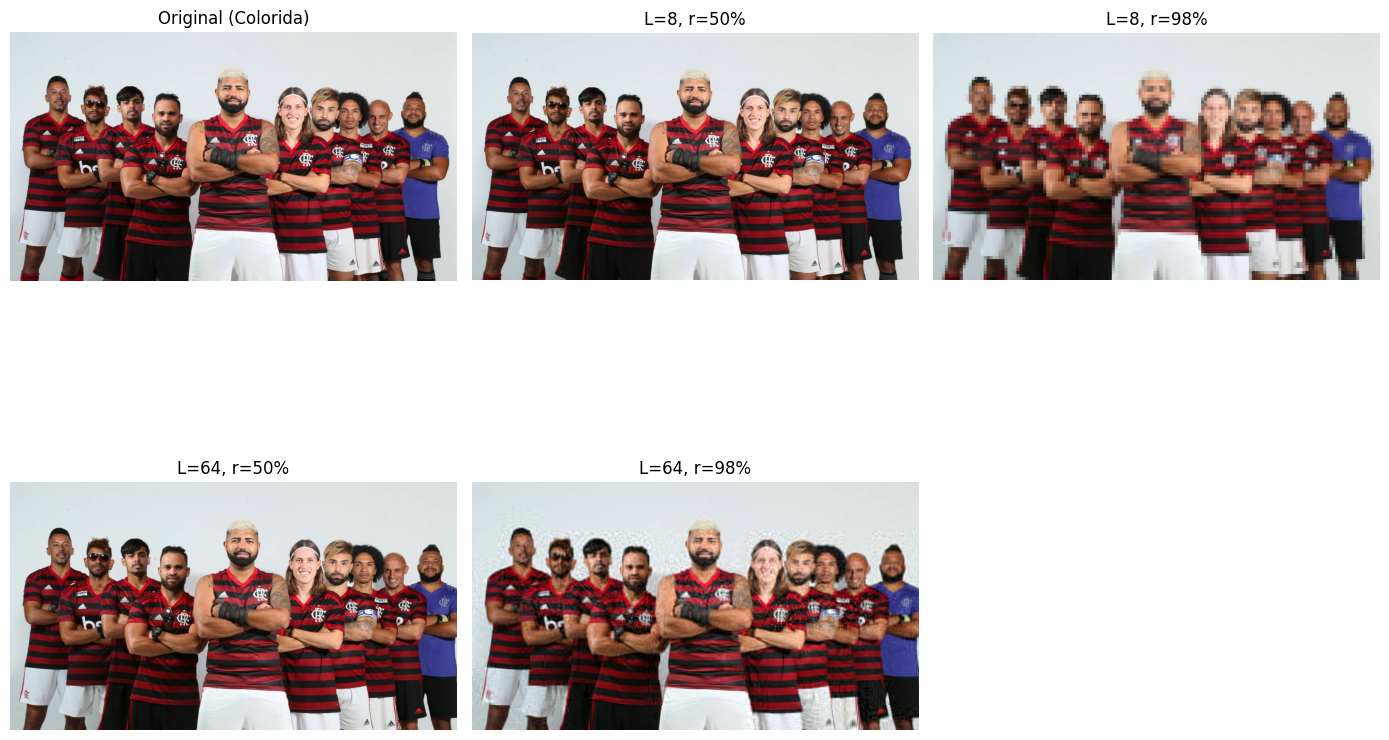

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import dct, idct
from google.colab import files

# 1. Fazer o upload da sua própria imagem colorida
print("Selecione a imagem COLORIDA do seu computador:")
uploaded = files.upload()

# Obtém o nome do arquivo enviado
nome_arquivo = list(uploaded.keys())[0]

# Carrega a imagem COLORIDA (em formato BGR pelo OpenCV)
img_bgr = cv2.imread(nome_arquivo, cv2.IMREAD_COLOR)
# Converte para RGB para exibir corretamente no Matplotlib
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Funções para DCT e IDCT bidimensional
def dct2(block):
    return dct(dct(block.astype(float), axis=0, norm='ortho'), axis=1, norm='ortho')

def idct2(block):
    return idct(idct(block, axis=0, norm='ortho'), axis=1, norm='ortho')

# Função principal de compressão por blocos para imagens coloridas
def comprimir_blocos_colorido(imagem_rgb, L, r_compressao):
    # Converte para o espaço YCbCr (padrão do JPEG) para separar brilho de cor
    img_ycbcr = cv2.cvtColor(imagem_rgb, cv2.COLOR_RGB2YCrCb)

    h, w, c = img_ycbcr.shape
    # Ajusta o tamanho da imagem para ser múltiplo exato de L
    h_novo = (h // L) * L
    w_novo = (w // L) * L
    img_corte = img_ycbcr[:h_novo, :w_novo].copy()

    img_reconstruida = np.zeros_like(img_corte, dtype=float)

    # Define quantos coeficientes manter por bloco
    total_coeficientes = L * L
    manter_qtd = int(round(total_coeficientes * (1.0 - r_compressao)))
    manter_qtd = max(1, manter_qtd) # Garante que pelo menos 1 coeficiente seja mantido

    # Processa cada um dos 3 canais (Y, Cr, Cb) de forma independente
    for canal in range(3):
        for i in range(0, h_novo, L):
            for j in range(0, w_novo, L):
                bloco = img_corte[i:i+L, j:j+L, canal]

                # 1. Aplicar DCT de 2D
                bloco_dct = dct2(bloco)

                # 2. Compressão: Filtrar por magnitude
                limiar = np.sort(np.abs(bloco_dct.ravel()))[::-1][manter_qtd - 1]
                bloco_dct_filtrado = np.where(np.abs(bloco_dct) >= limiar, bloco_dct, 0)

                # 3. Aplicar IDCT de 2D para reconstruir o bloco no canal atual
                img_reconstruida[i:i+L, j:j+L, canal] = idct2(bloco_dct_filtrado)

    # Limita os valores entre 0 e 255 e converte para inteiros de 8 bits
    img_reconstruida = np.clip(img_reconstruida, 0, 255).astype(np.uint8)

    # Converte de volta para RGB para exibição
    return cv2.cvtColor(img_reconstruida, cv2.COLOR_YCrCb2RGB)

# Parâmetros solicitados
configuracoes = [
    {"L": 8, "r": 0.50, "label": "L=8, r=50%"},
    {"L": 8, "r": 0.98, "label": "L=8, r=98%"},
    {"L": 64, "r": 0.50, "label": "L=64, r=50%"},
    {"L": 64, "r": 0.98, "label": "L=64, r=98%"}
]

# Executar e plotar os resultados coloridos
plt.figure(figsize=(14, 10))
plt.subplot(2, 3, 1)
plt.imshow(img_rgb)
plt.title("Original (Colorida)")
plt.axis('off')

for idx, config in enumerate(configuracoes, start=2):
    resultado = comprimir_blocos_colorido(img_rgb, config["L"], config["r"])

    plt.subplot(2, 3, idx)
    plt.imshow(resultado)
    plt.title(config["label"])
    plt.axis('off')

plt.tight_layout()
plt.show()